# Optimization

**Lecture 6 · Wednesday, 21 October 2026 · Notebook 1 of 1**

We solve **one small consumer problem** in several ways. A consumer has a fixed budget and chooses quantities of two goods. The economic question stays the same; only the numerical method changes.

By the end, you should be able to define an objective, describe affordable choices, call an optimizer, and check the result.

**Already familiar:** functions and arguments, `for`, `if`, arrays, Boolean masks, `np.meshgrid`, f-strings and simple plots from Lectures 1–5. **New:** grid search, counting evaluations, `minimize_scalar` and a constrained optimizer.

## How to work

We work through this notebook together in class. Boxes marked **Try it yourself** are short tasks of at most 5 minutes: work on your own or with a neighbour, submit your answer in Socrative (room **PROGECON26**), and we go through the solution together.

More practice questions with hints are in **`Exercises.ipynb`**. **Problem Set 6** applies the same steps (grid, budget line, `minimize_scalar`, SLSQP) to CES utility.

**Table of contents**<a id='toc0_'></a>
- 1. [The consumer problem and a known answer](#toc1_)
- 2. [Grid search: try affordable bundles](#toc2_)
- 3. [Use monotonicity: search the budget line](#toc3_)
- 4. [One choice: `minimize_scalar`](#toc4_)
- 5. [Two choices: constrained optimization](#toc5_)
- 6. [Compare, check and summarise](#toc6_)

## 1. <a id='toc1_'></a>[The consumer problem and a known answer](#toc0_)

A **bundle** is a pair of quantities, $(x_1,x_2)$. Think of two divisible goods, such as kilograms of two foods. Fractions are allowed. All numbers here are **illustrative**, not observed prices or household data.

| Symbol / Python name | Meaning | Value |
| --- | --- | --- |
| $x_1,x_2$ / `x1`, `x2` | Quantities the consumer chooses | To be found |
| $I$ / `I` | Available budget, in money units | 10 |
| $p_1$ / `p1` | Price per unit of good 1 | 1 |
| $p_2$ / `p2` | Price per unit of good 2 | 2 |
| $\alpha$ / `alpha` | Preference weight on good 1 | 0.5 |

**Affordability:** total spending cannot exceed the budget.

$$p_1x_1+p_2x_2\leq I,\qquad x_1\geq0,\;x_2\geq0.$$

**Preferences:** we use Cobb–Douglas utility:

$$u(x_1,x_2)=x_1^{\alpha}x_2^{1-\alpha},\qquad 0<\alpha<1.$$

Utility is a way to **rank bundles**, not an amount of money. A higher value means a preferred bundle. With our parameters, $u=\sqrt{x_1x_2}$: having some of both goods is better than having only one.

The task is to find the **highest-utility affordable bundle**. No Lagrangian derivation is needed to follow the code.

### Import packages

`np` and `plt` are familiar. `optimize` is the part of SciPy that contains the numerical solvers used below. Everything is in this notebook: there is no helper `.py` file, widget or data download to set up.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

### Put the economic model into Python

The function takes quantities and the preference weight as inputs. We only evaluate it at **nonnegative quantities**. We do not replace infeasible choices with artificial utility values.

In [2]:
def u_func(x1, x2, alpha):
    """Utility from nonnegative quantities of the two goods."""
    return x1**alpha * x2**(1 - alpha)

# a. parameters
alpha = 0.5
I = 10.0
p1 = 1.0
p2 = 2.0

# b. evaluate one candidate, not an optimum
x1 = 2.0
x2 = 2.0
spending = p1*x1 + p2*x2

print(f'Spending: {spending:.2f}; budget: {I:.2f}')
print('Affordable:', spending <= I)
print(f'Utility: {u_func(x1, x2, alpha):.3f}')

Spending: 6.00; budget: 10.00
Affordable: True
Utility: 2.000


### A known answer helps us test our code

For this particular Cobb–Douglas example, the exact solution is known:

$$x_1^*=\alpha I/p_1,\qquad x_2^*=(1-\alpha)I/p_2.$$

The consumer spends the fraction $\alpha$ of the budget on good 1. We use this **benchmark** only to check numerical results; the methods below are never told the answer.

Most economic models have no such formula. That is why we need numerical methods. Section 5 shows how one small change to the problem already breaks this formula.

In [3]:
x1_true = alpha*I/p1
x2_true = (1 - alpha)*I/p2

print(f'Benchmark: ({x1_true:.3f}, {x2_true:.3f})')

Benchmark: (5.000, 2.500)


## 2. <a id='toc2_'></a>[Grid search: try affordable bundles](#toc0_)

A **grid** is a finite list of candidate values. `np.linspace(start, stop, N)` creates `N` evenly spaced values, including both endpoints.

The most we could afford of good 1 is `I/p1`; similarly, the maximum of good 2 is `I/p2`. We use **12 candidates for good 1 and 8 for good 2**. These separate limits do **not** guarantee that a pair is affordable: we still need the total-budget check.

Our algorithm is: **try a pair → check the budget → calculate utility → keep it if it is better**.

**Pause and predict:** there are $12\times8=96$ pairs. Roughly how many of them are affordable?

In [4]:
# a. small grids make it easy to see what is being tried
N1 = 12
N2 = 8
x1_grid = np.linspace(0.0, I/p1, N1)
x2_grid = np.linspace(0.0, I/p2, N2)
print('Candidates for good 1:', x1_grid)
print('Candidates for good 2:', x2_grid)

Candidates for good 1: [ 0.          0.90909091  1.81818182  2.72727273  3.63636364  4.54545455
  5.45454545  6.36363636  7.27272727  8.18181818  9.09090909 10.        ]
Candidates for good 2: [0.         0.71428571 1.42857143 2.14285714 2.85714286 3.57142857
 4.28571429 5.        ]


In [5]:
# a. initial best bundle and a counter
best_x1 = 0.0
best_x2 = 0.0
best_u = u_func(best_x1, best_x2, alpha)
n_tried = 0

# b. try every pair on the grid
for x1 in x1_grid:
    for x2 in x2_grid:
        n_tried += 1
        if p1*x1 + p2*x2 <= I:
            candidate_u = u_func(x1, x2, alpha)
            if candidate_u > best_u:
                best_x1 = x1
                best_x2 = x2
                best_u = candidate_u

# c. report the best affordable grid point
print(f'Pairs tried: {n_tried}')
print(f'Best grid bundle: ({best_x1:.3f}, {best_x2:.3f})')
print(f'Utility: {best_u:.3f}')
print(f'Budget left: {I - p1*best_x1 - p2*best_x2:.3f}')
print(f'Absolute error in good 1: {abs(best_x1 - x1_true):.3f}')

Pairs tried: 96
Best grid bundle: (5.455, 2.143)
Utility: 3.419
Budget left: 0.260
Absolute error in good 1: 0.455


### See which pairs were tried

`np.meshgrid` (Lecture 5) turns the two lists into all 96 pairs. A Boolean mask (Lecture 4) splits them into affordable and too expensive pairs. The straight line is the **budget line**: spending equals income.

Affordable pairs: 49 of 96


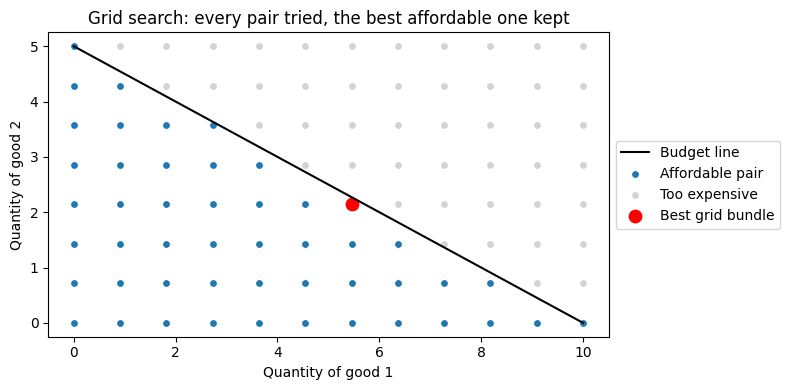

In [6]:
# a. all pairs as two 2D arrays, and a mask for affordability
x1_pairs, x2_pairs = np.meshgrid(x1_grid, x2_grid)
spending_pairs = p1*x1_pairs + p2*x2_pairs
affordable = spending_pairs <= I
too_expensive = spending_pairs > I
print('Affordable pairs:', np.sum(affordable), 'of', n_tried)

# b. budget line
x1_line = np.linspace(0.0, I/p1, 100)
x2_line = (I - p1*x1_line)/p2

# c. plot
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(x1_line, x2_line, color='black', label='Budget line')
ax.scatter(x1_pairs[affordable], x2_pairs[affordable], s=15, label='Affordable pair')
ax.scatter(x1_pairs[too_expensive], x2_pairs[too_expensive], s=15, color='lightgrey', label='Too expensive')
ax.scatter(best_x1, best_x2, s=80, color='red', label='Best grid bundle')
ax.set_xlabel('Quantity of good 1')
ax.set_ylabel('Quantity of good 2')
ax.set_title('Grid search: every pair tried, the best affordable one kept')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()
plt.show()

**What did we find?** The best affordable point **on this grid**, not the exact continuous optimum. It lies slightly **below** the budget line: some money is left unspent, because no grid pair sits exactly on the line near the optimum. The true best bundle can fall between grid points.

**Cost:** we tried 96 pairs, and about half of them were too expensive — wasted work. Doubling the number of points in **both** directions quadruples the pairs. With more goods, the number of pairs grows much faster.

**Try it yourself, 5 minutes:** Repeat the 2D grid search with `N1 = 24` and `N2 = 16`. Predict first: how many pairs will you try? Copy the loop above and use **new names** (e.g. `best_x1_fine`, `n_tried_fine`), so the results above are not overwritten. Print the pairs tried, the best bundle and the absolute error in good 1. Four times the effort: how much smaller is the error?

> **Socrative:** pairs tried and the error in good 1, rounded to two decimals.

## 3. <a id='toc3_'></a>[Use monotonicity: search the budget line](#toc0_)

For this consumer, an optimal bundle has positive amounts of both goods and **spends the whole budget**. With money left over, as in our 2D grid result, the consumer could buy more and improve the bundle. There is no saving decision in this model.

This lets us calculate good 2 from good 1:

$$x_2=\frac{I-p_1x_1}{p_2},\qquad 0\leq x_1\leq I/p_1.$$

**In words:** spend on good 1; divide the remaining money by the price of good 2. We now try **one list of choices**, not every pair of two lists. This use of increasing preferences is often called exploiting **monotonicity**.

In [7]:
# a. candidates along the budget line
N_line = 12
x1_line_grid = np.linspace(0.0, I/p1, N_line)
x2_line_grid = (I - p1*x1_line_grid)/p2
u_line_grid = u_func(x1_line_grid, x2_line_grid, alpha)

# b. find the position of the largest utility
best_index = np.argmax(u_line_grid)
x1_1d = x1_line_grid[best_index]
x2_1d = x2_line_grid[best_index]

print(f'Utility evaluations: {N_line}')
print(f'Best budget-line bundle: ({x1_1d:.3f}, {x2_1d:.3f})')
print(f'Budget left: {I - p1*x1_1d - p2*x2_1d:.3f}')
print(f'Absolute error in good 1: {abs(x1_1d - x1_true):.3f}')

Utility evaluations: 12
Best budget-line bundle: (4.545, 2.727)
Budget left: 0.000
Absolute error in good 1: 0.455


<details>
<summary><strong>Code reminder: arrays and argmax</strong></summary>

`np.argmax(values)` returns the **index**, or position, of the largest entry. It does not return the entry itself. Use square brackets to retrieve the entry at that position. If several entries tie, `np.argmax` returns the first.

`u_func` works on these arrays element by element, using the NumPy operations from Lecture 4. The entries with the same index belong to the same bundle.

</details>

### A fair comparison: the same number of tries

With only 12 tries, the line search is as accurate as the 96-pair grid and leaves no money unspent. Now give it the **same effort as the 2D grid: 96 tries**. Counting tries (candidate points checked) is a simple way to compare speed that does not depend on your computer. For a solver, the count of function evaluations, `.nfev`, plays the same role.

In [8]:
# a. 96 candidates along the budget line
N_fine = 96
x1_fine = np.linspace(0.0, I/p1, N_fine)
x2_fine = (I - p1*x1_fine)/p2
fine_index = np.argmax(u_func(x1_fine, x2_fine, alpha))
x1_fine_best = x1_fine[fine_index]
x2_fine_best = x2_fine[fine_index]

# b. compare effort and accuracy
print(f'{"Search":18s} {"Tries":>6s} {"Error in good 1":>16s}')
print(f'{"2D grid, 12 x 8":18s} {n_tried:6d} {abs(best_x1 - x1_true):16.3f}')
print(f'{"Budget line, 12":18s} {N_line:6d} {abs(x1_1d - x1_true):16.3f}')
print(f'{"Budget line, 96":18s} {N_fine:6d} {abs(x1_fine_best - x1_true):16.3f}')

Search              Tries  Error in good 1
2D grid, 12 x 8        96            0.455
Budget line, 12        12            0.455
Budget line, 96        96            0.053


Using the economics removed one dimension. The same 96 tries now give an error more than eight times smaller. More points still need not hit the exact optimum: the best of 96 points is close to 5, not equal to it.

**Try it yourself, 5 minutes:** Write a function `value_of_choice(x1, alpha, I, p1, p2)` that calculates $x_2$ from the budget line and returns utility. Evaluate it for `x1` equal to 2, 5 and 8 in a `for` loop and print each result with an f-string. Which choice is best? Problem Set 6 asks for the same function with CES utility.

> **Socrative:** the best of the three values of `x1` and its utility, rounded to two decimals.

## 4. <a id='toc4_'></a>[One choice: `minimize_scalar`](#toc0_)

A solver chooses where to evaluate the function rather than checking every point of a fixed grid.

`minimize_scalar` **minimizes** a function of one choice. We want to **maximize** utility, so we give it **negative utility**. For example, choosing between utility 2 and 3 is equivalent to choosing between objectives −2 and −3: the smaller objective corresponds to higher utility.

The input `x1` is the choice; `alpha`, `I`, `p1` and `p2` are parameters. `x2` is calculated inside the function.

In [9]:
def negative_utility(x1, alpha, I, p1, p2):
    """Negative utility when the entire budget is spent."""
    x2 = (I - p1*x1)/p2
    return -u_func(x1, x2, alpha)

### Give the function to the solver

Pass the **function name**, not a single evaluated value. `args` supplies its remaining inputs in the order of the function definition. `bounds` gives the allowed interval; `method='bounded'` tells the solver to respect that interval.

In [10]:
result_scalar = optimize.minimize_scalar(
    negative_utility,
    args=(alpha, I, p1, p2),
    bounds=(0.0, I/p1),
    method='bounded'
)

print('Solver success:', result_scalar.success)
print('Message:', result_scalar.message)

Solver success: True
Message: Solution found.


### Read and check the result

The returned object is a **result container**, not just one number. `.x` is the proposed choice; `.fun` is the minimized **negative** utility. `.success` is the solver's status, not a proof that our economic setup is correct. `.nfev` counts how often the solver evaluated our function.

The following guard stops the notebook if the solver reports a failure. Do not continue treating a failed run as an optimum.

In [11]:
if not result_scalar.success:
    raise RuntimeError(result_scalar.message)

x1_scalar = result_scalar.x
x2_scalar = (I - p1*x1_scalar)/p2

print(f'Bundle: ({x1_scalar:.6f}, {x2_scalar:.6f})')
print(f'Utility: {-result_scalar.fun:.6f}')
print(f'Budget left: {I - p1*x1_scalar - p2*x2_scalar:.8f}')
print(f'Absolute error in good 1: {abs(x1_scalar - x1_true):.8f}')
print(f'Function evaluations: {result_scalar.nfev}')

Bundle: (5.000000, 2.500000)
Utility: 3.535534
Budget left: 0.00000000
Absolute error in good 1: 0.00000000
Function evaluations: 6


### Plot the objective we actually minimize

A low point of negative utility is a high point of utility. Here the objective has one valley on the feasible interval. In problems with several valleys, one solver call is not a global-optimum guarantee.

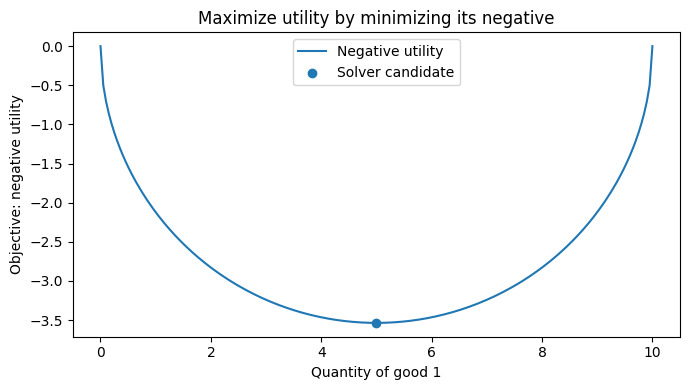

In [12]:
x1_plot = np.linspace(0.0, I/p1, 200)
objective_plot = negative_utility(x1_plot, alpha, I, p1, p2)

fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(x1_plot, objective_plot, label='Negative utility')
ax.scatter(x1_scalar, result_scalar.fun, label='Solver candidate')
ax.set_xlabel('Quantity of good 1')
ax.set_ylabel('Objective: negative utility')
ax.set_title('Maximize utility by minimizing its negative')
ax.legend()
fig.tight_layout()
plt.show()

**Effort:** the solver needed only a handful of evaluations (see `.nfev`) and is far more accurate than a 96-point grid. It picks each new point using the values it has already seen.

**Boundary check:** a bounded scalar solver searches inside the supplied interval; a true optimum can also be at an endpoint. In a new problem, compare the endpoints as well. Here both endpoints give zero utility, whereas an interior bundle gives positive utility.

**Precision:** default settings are sufficient for our example. Printing many decimal places does not make the answer more accurate. Use feasibility, the benchmark and a plot to judge the result.

**Try it yourself, 5 minutes:** The price of good 1 doubles to 2. Predict first: what happens to $x_1$ and to $x_2$? Then solve with `minimize_scalar`. Store the new price as `p1_high`, so `p1` stays unchanged for the rest of the notebook, and remember that the price enters both `args` and `bounds`. Check `.success` before you print the bundle.

> **Socrative:** the new bundle, and one sentence on what happened to good 2.

## 5. <a id='toc5_'></a>[Two choices: constrained optimization](#toc0_)

Sometimes we cannot easily eliminate a choice. We can instead give **both quantities** to `optimize.minimize`.

The first input is now an array `x`: `x[0]` is good 1 and `x[1]` is good 2. The objective still returns **one number**: negative utility.

We supply two kinds of restrictions:

- **Bounds:** a separate lower and upper limit for each quantity.
- **Budget inequality:** one restriction involving **both** quantities.

For SciPy's inequality-constraint dictionary, the function must be **nonnegative** at an allowed choice. Therefore we return **income minus spending**, not spending minus income.

In [13]:
def negative_utility_bundle(x, alpha):
    """The two entries in x are the two quantities."""
    return -u_func(x[0], x[1], alpha)


def budget_left(x, I, p1, p2):
    """A nonnegative value means that the bundle is affordable."""
    return I - p1*x[0] - p2*x[1]

### Describe the restrictions

The dictionary contains the constraint type (`'ineq'`), the function (`'fun'`) and its additional arguments (`'args'`). The initial guess is affordable and contains some of both goods.

In [14]:
quantity_bounds = [(0.0, I/p1), (0.0, I/p2)]
budget_constraint = {
    'type': 'ineq',
    'fun': budget_left,
    'args': (I, p1, p2)
}
initial_guess = np.array([0.4*I/p1, 0.4*I/p2])

print('Budget left at the initial guess:', budget_left(initial_guess, I, p1, p2))

Budget left at the initial guess: 2.0


### Call the constrained solver

`SLSQP` is the method name. For now, learn the interface rather than its internal algorithm. It accepts bounds and the budget restriction. `args=(alpha,)` is a **one-element tuple**; the comma is needed.

In [15]:
result_slsqp = optimize.minimize(
    negative_utility_bundle,
    x0=initial_guess,
    args=(alpha,),
    method='SLSQP',
    bounds=quantity_bounds,
    constraints=budget_constraint
)

print('Solver success:', result_slsqp.success)
print('Message:', result_slsqp.message)
if not result_slsqp.success:
    raise RuntimeError(result_slsqp.message)

x1_slsqp, x2_slsqp = result_slsqp.x
print(f'Bundle: ({x1_slsqp:.6f}, {x2_slsqp:.6f})')
print(f'Utility: {u_func(x1_slsqp, x2_slsqp, alpha):.6f}')
print(f'Budget left: {budget_left(result_slsqp.x, I, p1, p2):.8f}')
print(f'Function evaluations: {result_slsqp.nfev}')

Solver success: True
Message: Optimization terminated successfully
Bundle: (4.999986, 2.500007)
Utility: 3.535534
Budget left: -0.00000000
Function evaluations: 18


A printed `-0.00000000` is a tiny negative number rounded for printing. It is floating-point and solver error, not overspending; a substantial negative remainder would not be affordable.

With two choices, the solver needs more evaluations than `minimize_scalar` did, but still far fewer than a grid.

### Does the starting point matter?

The solver starts at `x0` and improves the bundle step by step. We try three affordable starting bundles and compare where they end.

In [16]:
starts = [np.array([1.0, 1.0]), initial_guess, np.array([9.0, 0.4])]

for x0 in starts:
    result = optimize.minimize(
        negative_utility_bundle,
        x0=x0,
        args=(alpha,),
        method='SLSQP',
        bounds=quantity_bounds,
        constraints=budget_constraint
    )
    print(f'start {x0} -> bundle ({result.x[0]:.4f}, {result.x[1]:.4f}); '
          f'evaluations: {result.nfev}; success: {result.success}')

start [1. 1.] -> bundle (4.9999, 2.5001); evaluations: 21; success: True
start [4. 2.] -> bundle (5.0000, 2.5000); evaluations: 18; success: True
start [9.  0.4] -> bundle (5.0008, 2.4996); evaluations: 18; success: True


All three starts reach approximately (5, 2.5). The last digits differ because the solver stops once further improvements are tiny.

This utility has a **single peak** on the budget line, so every start climbs the same hill. If an objective has **several peaks**, a solver returns a **local** optimum near its start. Then try several starts and keep the best: one run is not a guarantee of the **global** optimum.

### When the formula stops working: a purchase cap

Suppose a shop sells **at most 3 units of good 1** per customer. The benchmark formula says the consumer wants 5 units, which is no longer allowed, so the formula from Section 1 no longer answers the question. For the solver, the cap is just a different upper bound.

**Pause and predict:** will the capped consumer still spend the whole budget?

In [17]:
capped_bounds = [(0.0, 3.0), (0.0, I/p2)]

result_cap = optimize.minimize(
    negative_utility_bundle,
    x0=np.array([1.0, 1.0]),
    args=(alpha,),
    method='SLSQP',
    bounds=capped_bounds,
    constraints=budget_constraint
)
if not result_cap.success:
    raise RuntimeError(result_cap.message)

x1_cap, x2_cap = result_cap.x
print(f'Capped bundle: ({x1_cap:.4f}, {x2_cap:.4f})')
print(f'Budget left: {budget_left(result_cap.x, I, p1, p2):.6f}')
print(f'The formula would say x1 = {x1_true:.1f}, which breaks the cap.')

Capped bundle: (3.0000, 3.5000)
Budget left: -0.000000
The formula would say x1 = 5.0, which breaks the cap.


The consumer buys the maximum of 3 units of good 1 and spends the remaining money on good 2. Both restrictions are tight, but they are **different** restrictions: the cap limits one quantity, while the budget links both quantities. Bounds alone can never express a shared budget.

**Try it yourself, 5 minutes:** Raise the cap to **6 units** of good 1 and solve again. Predict first: will the cap still matter? Check `.success`, then print the bundle and the budget left.

> **Socrative:** the bundle, and whether the cap binds (yes or no).

## 6. <a id='toc6_'></a>[Compare, check and summarise](#toc0_)

All the numerical approaches answer the **same** economic question (without the cap). The benchmark is a test, not an input to the solver. The last column counts tries: candidate points checked by a grid, or function evaluations (`.nfev`) by a solver.

In [18]:
names = ['2D grid, 12 x 8', 'Budget line, 12', 'Budget line, 96', 'Scalar solver', 'SLSQP']
x1_results = [best_x1, x1_1d, x1_fine_best, x1_scalar, x1_slsqp]
x2_results = [best_x2, x2_1d, x2_fine_best, x2_scalar, x2_slsqp]
evaluations = [n_tried, N_line, N_fine, result_scalar.nfev, result_slsqp.nfev]

print(f'{"Method":16s} {"x1":>8s} {"x2":>8s} {"Budget left":>12s} {"Tries":>6s}')
for name, x1, x2, n in zip(names, x1_results, x2_results, evaluations):
    remaining = I - p1*x1 - p2*x2
    print(f'{name:16s} {x1:8.4f} {x2:8.4f} {remaining:12.4f} {n:6d}')

print(f'Benchmark: x1 = {x1_true:.4f}, x2 = {x2_true:.4f}')

Method                 x1       x2  Budget left  Tries
2D grid, 12 x 8    5.4545   2.1429       0.2597     96
Budget line, 12    4.5455   2.7273       0.0000     12
Budget line, 96    4.9474   2.5263       0.0000     96
Scalar solver      5.0000   2.5000       0.0000      6
SLSQP              5.0000   2.5000      -0.0000     18
Benchmark: x1 = 5.0000, x2 = 2.5000


### All results in one picture

We zoom in around the benchmark (dashed lines) so that the small differences are visible. The two solvers land on top of each other.

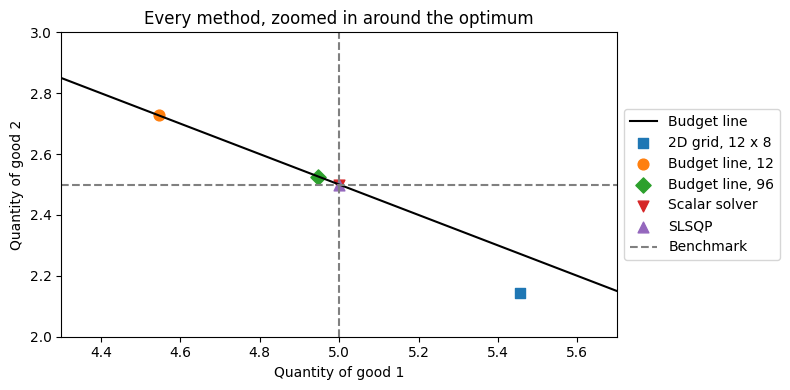

In [19]:
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(x1_line, x2_line, color='black', label='Budget line')
markers = ['s', 'o', 'D', 'v', '^']
for name, x1, x2, marker in zip(names, x1_results, x2_results, markers):
    ax.scatter(x1, x2, s=60, marker=marker, label=name)
ax.axvline(x1_true, color='grey', linestyle='--', label='Benchmark')
ax.axhline(x2_true, color='grey', linestyle='--')
ax.set_xlim(4.3, 5.7)
ax.set_ylim(2.0, 3.0)
ax.set_xlabel('Quantity of good 1')
ax.set_ylabel('Quantity of good 2')
ax.set_title('Every method, zoomed in around the optimum')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()
plt.show()

### What to check every time

**Meaning:** did we minimize the correct objective? **Status:** did the solver report success? **Feasibility:** do quantities and spending obey the restrictions? **Reasonableness:** does the result agree with the plot, nearby feasible alternatives, another starting point, or a known special case?

For example, `abs(budget_left(result_slsqp.x, I, p1, p2)) < 1e-6` checks whether this consumer has approximately exhausted the budget. It is **not** a universal test of optimality: some other economic models optimally leave resources unused.

| Method | What it searches | Main lesson |
| --- | --- | --- |
| 2D grid | Every listed pair, rejecting unaffordable ones | Transparent, but many wasted tries |
| Budget-line grid | Listed choices of good 1 | Economic structure removes a dimension: same tries, more accuracy |
| `minimize_scalar` | One choice within an interval | Minimize negative utility; few evaluations; check boundaries |
| `minimize` with SLSQP | Both quantities, with restrictions | Bounds and a shared budget are different; try several starts |

You do not need to memorize solver syntax. `Exercises.ipynb` and Problem Set 6 practise the same steps.

### References

References: [SciPy minimize_scalar](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize_scalar.html), [SciPy minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html), and [SLSQP settings](https://docs.scipy.org/doc/scipy/reference/optimize.minimize-slsqp.html).